In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor


Final Strategy Value: $ 30753.11
Final Market Value: $ 22641.82
Sharpe Ratio: 4.45
Max Drawdown: -3.4 %


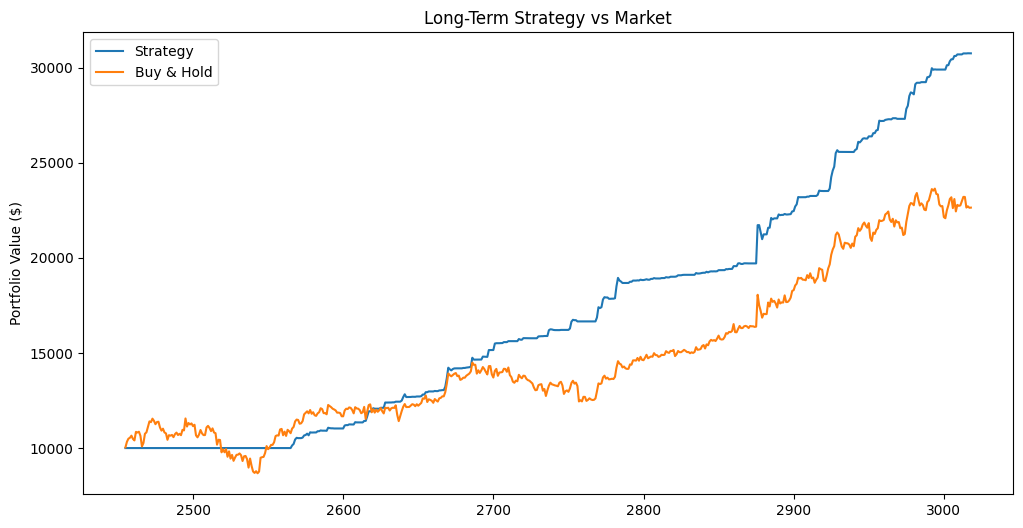

In [15]:


# =============================
# Load and Prepare Data
# =============================
df = pd.read_csv("stock_data.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values("Date")

df['Return'] = df['Close'].pct_change()

# =============================
# Feature Engineering
# =============================

# Trend
df['SMA_20'] = df['Close'].rolling(20).mean()
df['SMA_50'] = df['Close'].rolling(50).mean()
df['SMA_200'] = df['Close'].rolling(200).mean()

# Momentum
df['Momentum_5'] = df['Close'].pct_change(5)

# Volatility
df['Volatility_10'] = df['Return'].rolling(10).std()

# Lag Returns
for i in range(1, 6):
    df[f'lag_{i}'] = df['Return'].shift(i)

df = df.dropna()

# Regime Filter (Long Only in Bull Markets)
df['Regime'] = df['Close'] > df['SMA_200']

# =============================
# Features and Target
# =============================
features = [
    'lag_1','lag_2','lag_3','lag_4','lag_5',
    'Momentum_5','Volatility_10'
]

X = df[features]
y = df['Return']

# =============================
# Train/Test Split (Time Aware)
# =============================
split_index = int(len(df) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

df_test = df.iloc[split_index:].copy()

# =============================
# Model (Nonlinear)
# =============================
model = RandomForestRegressor(
    n_estimators=400,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42
)

model.fit(X_train, y_train)

df_test['Predicted_Return'] = model.predict(X_test)

# =============================
# Trading Logic
# =============================

# Confidence threshold
threshold = 0.001

# Position sizing based on prediction strength
df_test['Position_Size'] = np.clip(
    df_test['Predicted_Return'] * 100,
    0,
    1
)

# Apply regime filter
df_test['Position_Size'] = np.where(
    df_test['Regime'],
    df_test['Position_Size'],
    0
)

# Strategy return
df_test['Strategy'] = df_test['Position_Size'] * df_test['Return']

# Stop loss cap (-2%)
df_test['Strategy'] = np.where(
    df_test['Strategy'] < -0.02,
    -0.02,
    df_test['Strategy']
)

# =============================
# Portfolio Calculation
# =============================
df_test['Cumulative_Strategy'] = (1 + df_test['Strategy']).cumprod()
df_test['Cumulative_Market'] = (1 + df_test['Return']).cumprod()

initial_investment = 10000

df_test['Strategy_Value'] = initial_investment * df_test['Cumulative_Strategy']
df_test['Market_Value'] = initial_investment * df_test['Cumulative_Market']

# =============================
# Performance Metrics
# =============================

final_strategy = df_test['Strategy_Value'].iloc[-1]
final_market = df_test['Market_Value'].iloc[-1]

sharpe = (
    df_test['Strategy'].mean() /
    df_test['Strategy'].std()
) * np.sqrt(252)

max_drawdown = (
    df_test['Strategy_Value'] /
    df_test['Strategy_Value'].cummax() - 1
).min()

print("Final Strategy Value: $", round(final_strategy, 2))
print("Final Market Value: $", round(final_market, 2))
print("Sharpe Ratio:", round(sharpe, 2))
print("Max Drawdown:", round(max_drawdown * 100, 2), "%")

# =============================
# Plot
# =============================
plt.figure(figsize=(12,6))
plt.plot(df_test['Strategy_Value'], label='Strategy')
plt.plot(df_test['Market_Value'], label='Buy & Hold')
plt.legend()
plt.title("Long-Term Strategy vs Market")
plt.ylabel("Portfolio Value ($)")
plt.show()


===== PERFORMANCE =====
Final Strategy Value: $ 2131051.33
Final Market Value: $ 28887.51
Annual Return: 48.7 %
Sharpe Ratio: 4.0
Max Drawdown: -6.63 %


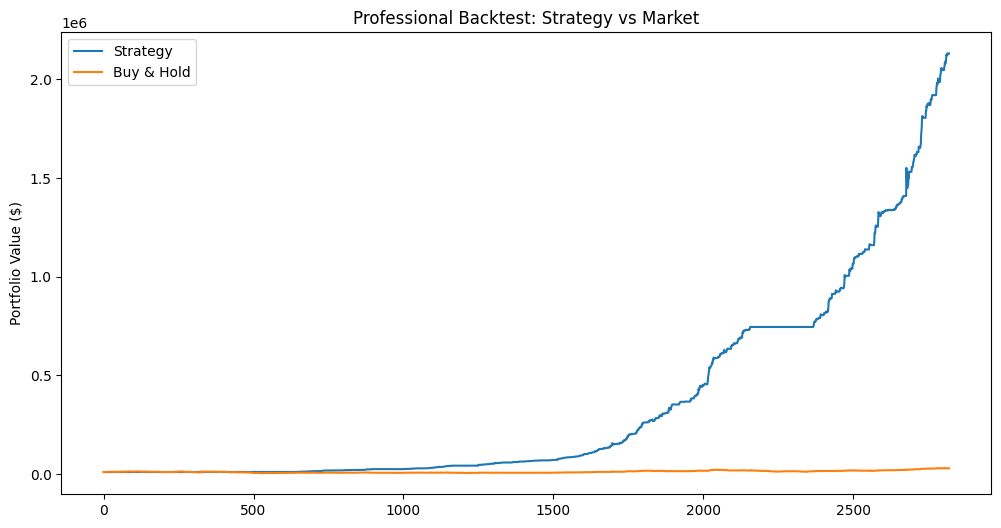

In [16]:
# =====================================
# CONFIGURATION
# =====================================
INITIAL_CAPITAL = 10000
TRANSACTION_COST = 0.0005   # 0.05% per trade
SLIPPAGE = 0.0005
WALK_FORWARD_WINDOW = 500   # rolling training window

# =====================================
# LOAD DATA
# =====================================
df = pd.read_csv("stock_data.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values("Date").reset_index(drop=True)

df['Return'] = df['Close'].pct_change()

# =====================================
# FEATURE ENGINEERING
# =====================================
df['SMA_50'] = df['Close'].rolling(50).mean()
df['SMA_200'] = df['Close'].rolling(200).mean()
df['Momentum_5'] = df['Close'].pct_change(5)
df['Volatility_10'] = df['Return'].rolling(10).std()

for i in range(1, 6):
    df[f'lag_{i}'] = df['Return'].shift(i)

df = df.dropna().reset_index(drop=True)

features = [
    'lag_1','lag_2','lag_3','lag_4','lag_5',
    'Momentum_5','Volatility_10'
]

# =====================================
# WALK-FORWARD BACKTEST
# =====================================
df['Predicted_Return'] = 0.0

for i in range(WALK_FORWARD_WINDOW, len(df)):
    train = df.iloc[i-WALK_FORWARD_WINDOW:i]
    test = df.iloc[i:i+1]

    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42
    )

    model.fit(train[features], train['Return'])
    prediction = model.predict(test[features])[0]
    df.loc[i, 'Predicted_Return'] = prediction

# =====================================
# STRATEGY LOGIC
# =====================================
df['Regime'] = df['Close'] > df['SMA_200']
threshold = 0.001

df['Position'] = np.where(
    (df['Predicted_Return'] > threshold) & (df['Regime']),
    np.clip(df['Predicted_Return'] * 100, 0, 1),
    0
)

# Apply transaction costs
df['Trade'] = df['Position'].diff().abs()
df['Costs'] = df['Trade'] * (TRANSACTION_COST + SLIPPAGE)

df['Strategy_Return'] = (
    df['Position'] * df['Return']
    - df['Costs']
)

# Stop loss cap
df['Strategy_Return'] = np.where(
    df['Strategy_Return'] < -0.03,
    -0.03,
    df['Strategy_Return']
)

# =====================================
# PERFORMANCE CALCULATION
# =====================================
df['Strategy_Value'] = INITIAL_CAPITAL * (1 + df['Strategy_Return']).cumprod()
df['Market_Value'] = INITIAL_CAPITAL * (1 + df['Return']).cumprod()

# =====================================
# METRICS
# =====================================
def performance_metrics(returns):
    annual_return = returns.mean() * 252
    annual_vol = returns.std() * np.sqrt(252)
    sharpe = annual_return / annual_vol if annual_vol != 0 else 0

    cumulative = (1 + returns).cumprod()
    drawdown = cumulative / cumulative.cummax() - 1
    max_dd = drawdown.min()

    return annual_return, sharpe, max_dd

ann_ret, sharpe, max_dd = performance_metrics(df['Strategy_Return'])

print("\n===== PERFORMANCE =====")
print("Final Strategy Value: $", round(df['Strategy_Value'].iloc[-1],2))
print("Final Market Value: $", round(df['Market_Value'].iloc[-1],2))
print("Annual Return:", round(ann_ret*100,2), "%")
print("Sharpe Ratio:", round(sharpe,2))
print("Max Drawdown:", round(max_dd*100,2), "%")

# =====================================
# PLOT
# =====================================
plt.figure(figsize=(12,6))
plt.plot(df['Strategy_Value'], label="Strategy")
plt.plot(df['Market_Value'], label="Buy & Hold")
plt.legend()
plt.title("Professional Backtest: Strategy vs Market")
plt.ylabel("Portfolio Value ($)")
plt.show()